In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.metrics import (MARTS, monthly_kpis, first_two_purchases,
                         repeat_rate_within, cohort_matrix, MATURE_UNTIL)

facts = pd.read_parquet(MARTS / "order_facts.parquet")
seller_months = pd.read_parquet(MARTS / "seller_months.parquet")
DATA_END = facts["purchase_date"].max()
cust = first_two_purchases(facts)

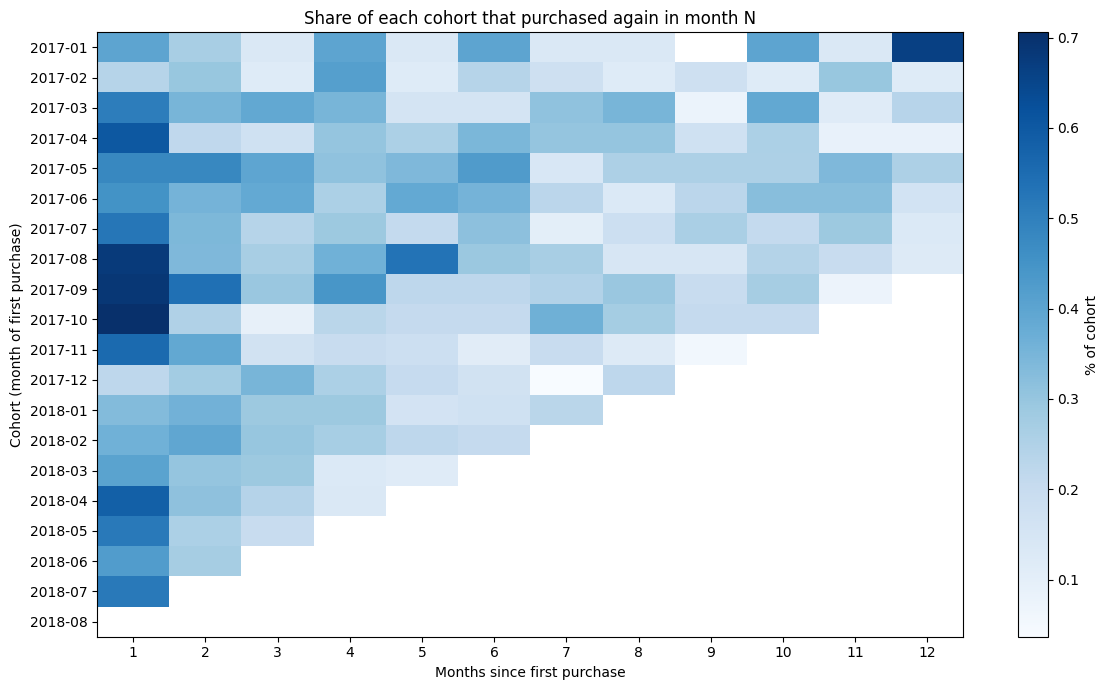

Average month-1 retention: 0.48%
Average month-3 retention: 0.25%


In [ ]:
#The cohort matrix: what does retention look like, month by month?


events = facts.loc[facts["is_valid_purchase"], ["customer_unique_id", "purchase_month"]]
cm = cohort_matrix(events, "customer_unique_id", "purchase_month")

show = cm.drop(columns=0).iloc[:, :12]     # month 0 is always 100% — it would crush the colour scale
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(show.values * 100, cmap="Blues", aspect="auto")
ax.set_xticks(range(show.shape[1]), labels=show.columns)
ax.set_yticks(range(show.shape[0]), labels=show.index)
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Cohort (month of first purchase)")
ax.set_title("Share of each cohort that purchased again in month N")
fig.colorbar(im, label="% of cohort")
plt.tight_layout()
plt.savefig("../reports/01_cohort_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average month-1 retention: {cm[1].mean():.2%}")
print(f"Average month-3 retention: {cm[3].mean():.2%}")

1. What does Month 0 actually mean?
Month 0 is the very month customers made their first purchase.
By definition, 100% of the customers in that cohort bought something in Month 0 (because that's literally how they got added to the cohort in the first place!).
So the column for Month 0 is just: [100%, 100%, 100%, 100%, ...] all the way down.
2. What happens in Months 1, 2, 3...?
In e-commerce, retention is naturally quite low:

Month 1 might be 3.5%
Month 2 might be 2.1%
Month 3 might be 1.8%
Month 6 might be 0.8%
Notice the huge gap: Month 0 is 100%, but everything else is between 0% and 4%.

   days  repeat_rate  eligible_customers
0    30     0.006678               88794
1    60     0.010323               82827
2    90     0.013073               76878
3   180     0.019899               57288
4   270     0.026374               38598
5   365     0.033370               21936


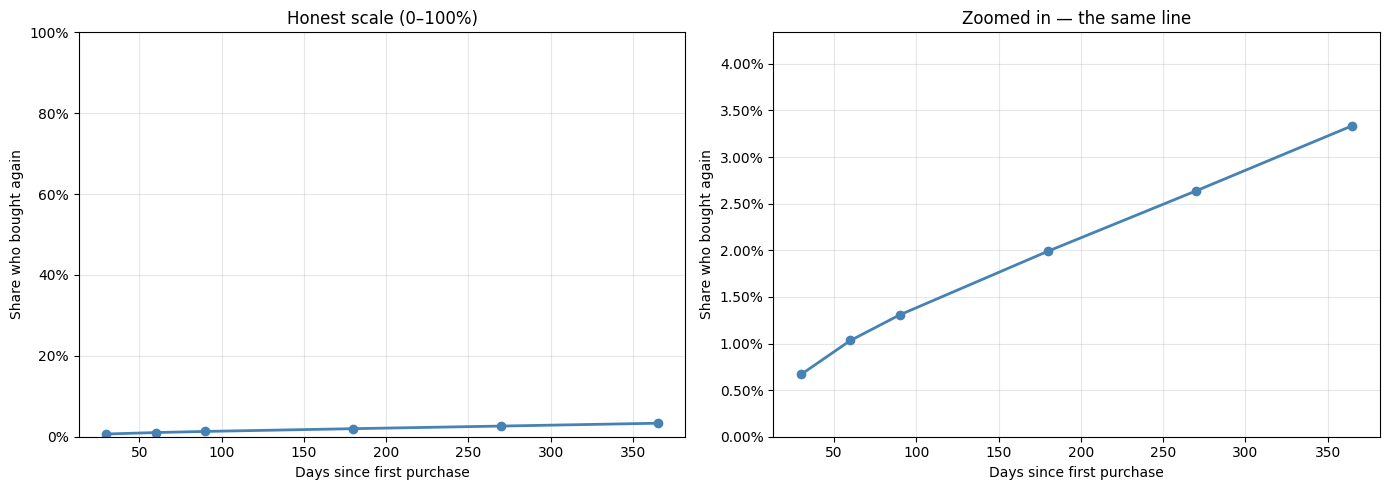

In [ ]:
##The censoring-aware retention curve (and two honest axes)


from matplotlib.ticker import PercentFormatter

windows = [30, 60, 90, 180, 270, 365]
curve = pd.DataFrame(
    [(w, *repeat_rate_within(cust, w, DATA_END)) for w in windows],
    columns=["days", "repeat_rate", "eligible_customers"],
)
print(curve)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top, title in zip(axes, [1.0, curve["repeat_rate"].max() * 1.3],
                          ["Honest scale (0–100%)", "Zoomed in — the same line"]):
    ax.plot(curve["days"], curve["repeat_rate"], marker="o", lw=2, color="steelblue")
    ax.set_ylim(0, top)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("Days since first purchase")
    ax.set_ylabel("Share who bought again")
    ax.set_title(title)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/02_retention_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Which one belongs in the dashboard?
Both, or the honest scale paired with an explicit KPI callout.
If you only show the zoomed chart, stakeholders may celebrate a curve that "steeply climbs 5x" (from 0.67% to 3.3%), missing the reality that 96.7% of customers never return.
If you only show the flat floor chart, stakeholders cannot see the shape of the decay (e.g., that repeat behavior slows down after 90–180 days).
What does choosing the zoomed-in chart alone say about the analyst?
It suggests the analyst is optimizing for optics over truth—framing a vanity metric to make retention look strong and growing, rather than acknowledging that the business is overwhelmingly a single-transaction/acquisition-driven model.

count    2054.000000
mean      113.693281
std       113.117496
min         1.000000
25%        23.000000
50%        74.000000
75%       174.750000
max       583.000000
Name: days_to_second, dtype: float64
days_to_second
(0, 7]         0.103
(7, 30]        0.195
(30, 90]       0.252
(90, 180]      0.211
(180, 365]     0.199
(365, 1000]    0.039
Name: proportion, dtype: float64


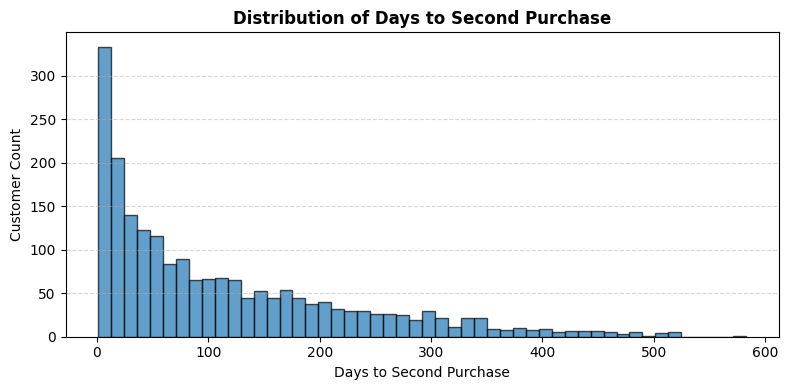

In [ ]:
#When do repeaters come back?


rep = cust.dropna(subset=["days_to_second"])
print(rep["days_to_second"].describe())
bins = [0, 7, 30, 90, 180, 365, 1000]
print(pd.cut(rep["days_to_second"], bins=bins).value_counts(normalize=True).sort_index().round(3))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rep["days_to_second"], bins=50, color="#1f77b4", edgecolor="black", alpha=0.7)
ax.set_title("Distribution of Days to Second Purchase", fontsize=12, fontweight="bold")
ax.set_xlabel("Days to Second Purchase")
ax.set_ylabel("Customer Count")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../reports/03_first_experience_repeat.png", dpi=300)
plt.show()


                sum  count    rate  ci_low  ci_high
first_on_time                                      
False            62   3956  0.0157  0.0122   0.0200
True           1060  52220  0.0203  0.0191   0.0215
              sum  count    rate  ci_low  ci_high
first_review                                     
1              98   5674  0.0173  0.0142   0.0210
2              27   1794  0.0151  0.0104   0.0218
3              97   4890  0.0198  0.0163   0.0241
4             205  11195  0.0183  0.0160   0.0210
5             690  32206  0.0214  0.0199   0.0231


FileNotFoundError: [Errno 2] No such file or directory: 'reports/03_first_experience_repeat.png'

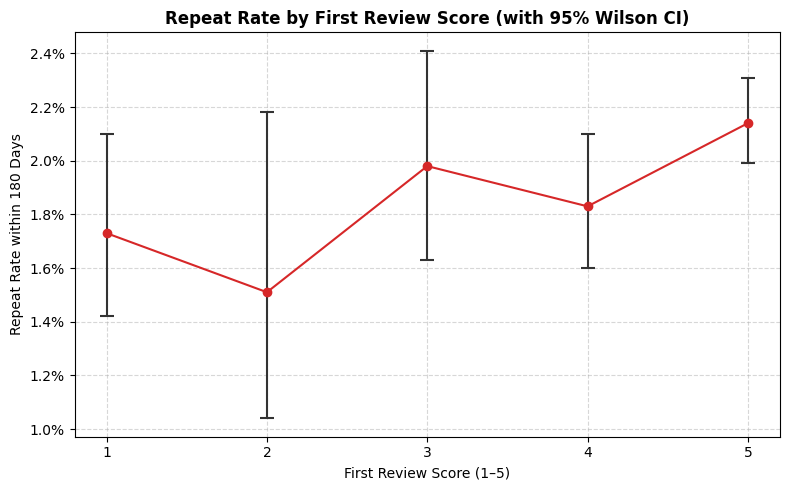

In [ ]:
from statsmodels.stats.proportion import proportion_confint

H = 180  # horizon in days — only customers observed for ≥ H days are included

first = facts.merge(cust[["customer_unique_id", "first_date", "days_to_second"]],
                    left_on=["customer_unique_id", "purchase_date"],
                    right_on=["customer_unique_id", "first_date"])
first = first[first["is_delivered"]]

exp = first.groupby("customer_unique_id").agg(
    first_on_time=("is_on_time", "min"),      # all first-day orders on time?
    first_review=("review_score", "min"),     # worst review of the first day
    first_date=("first_date", "first"),
    days_to_second=("days_to_second", "first"),
).reset_index()

elig = exp[exp["first_date"] <= DATA_END - pd.Timedelta(days=H)].copy()
elig["came_back"] = elig["days_to_second"] <= H

def rate_table(df, by):
    t = df.groupby(by)["came_back"].agg(["sum", "count"])
    t["rate"] = t["sum"] / t["count"]
    t["ci_low"], t["ci_high"] = proportion_confint(t["sum"], t["count"], method="wilson")
    return t.round(4)

print(rate_table(elig, "first_on_time"))
print(rate_table(elig, "first_review"))








import matplotlib.pyplot as plt

# Compute the table
t_review = rate_table(elig, "first_review")

# Calculate asymmetric error bar heights
yerr_lower = t_review["rate"] - t_review["ci_low"]
yerr_upper = t_review["ci_high"] - t_review["rate"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x=t_review.index,
    y=t_review["rate"],
    yerr=[yerr_lower, yerr_upper],
    fmt="o-",
    capsize=5,
    capthick=1.5,
    color="#d62728",
    ecolor="#333333",
    markersize=6,
    linewidth=1.5
)

ax.set_title("Repeat Rate by First Review Score (with 95% Wilson CI)", fontsize=12, fontweight="bold")
ax.set_xlabel("First Review Score (1–5)")
ax.set_ylabel("Repeat Rate within 180 Days")
ax.set_xticks(t_review.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../reports/03_first_experience_repeat.png", dpi=300)
plt.show()


